<a href="https://colab.research.google.com/github/VaggelisApostolou/Challenges-in-Detecting-Toxic-Language-in-Greek-Sports-Social-Media/blob/main/Null_Prompts_XLM_RoBERTa(MLM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [ ]:
!pip install --upgrade transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


In [ ]:
import os, random, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from transformers import (
    XLMRobertaTokenizerFast,
    XLMRobertaConfig,
    XLMRobertaForSequenceClassification,
    XLMRobertaForMaskedLM,
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM,
    get_linear_schedule_with_warmup,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)
from datasets import load_dataset
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, classification_report, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
XLM_CHECKPOINT = "xlm-roberta-base"
MASKED_XLM = "/content/drive/MyDrive/Toxic language in football Research/models/my_domain_adapted_model"

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Toxic language in football Research/final_labeled_batches/final_labeled_language.csv"

# **Dataset Analysis**

In [ ]:
df = pd.read_csv(DATA_PATH)

In [ ]:
print(df['language'].value_counts())

language
en    4999
el    1001
Name: count, dtype: int64


In [ ]:
df_en = df[df['language'] == 'en']
df_el = df[df['language'] == 'el']

In [ ]:
print(df_en['label'].value_counts())
print(df_el['label'].value_counts())

label
Non-toxic    4721
Toxic         278
Name: count, dtype: int64
label
Non-toxic    751
Toxic        250
Name: count, dtype: int64


# **Train / Validation / Test Splits**

In [ ]:
df['label_num'] = df['label'].map({'Non-toxic': 0, 'Toxic': 1})

X = df['text'].values
y = df['label_num'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, stratify=y_train_val, random_state=42
)

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Train samples: 4200
Validation samples: 600
Test samples: 1200


# **Tokenizer Initialization & Verbalizers Check**

In [ ]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained(XLM_CHECKPOINT)

word_non_toxic = " Good"
word_toxic = " Bad"

tokens_non_toxic = tokenizer.encode(word_non_toxic, add_special_tokens=False)
tokens_toxic = tokenizer.encode(word_toxic, add_special_tokens=False)

if len(tokens_non_toxic) > 1 or len(tokens_toxic) > 1:
    print(f"ΠΡΟΣΟΧΗ: Κάποια λέξη 'σπάει' σε sub-tokens!")
    print(f"'{word_non_toxic}' -> {tokenizer.convert_ids_to_tokens(tokens_non_toxic)}")
    print(f"'{word_toxic}' -> {tokenizer.convert_ids_to_tokens(tokens_toxic)}")
    raise ValueError("Επίλεξε άλλες λέξεις για verbalizers που να είναι 1 μόνο token.")

v0_id = tokens_non_toxic[0]
v1_id = tokens_toxic[0]

print(f"Token ID για '{word_non_toxic}': {v0_id}")
print(f"Token ID για '{word_toxic}': {v1_id}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Token ID για ' Good': 18621
Token ID για ' Bad': 12745


# **Null Prompts Dataset Creation**

In [ ]:
class NullPromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        max_tokens = self.max_length - 3
        if len(tokens) > max_tokens:
            tokens = tokens[:max_tokens]

        input_ids = [self.tokenizer.bos_token_id] + tokens + [self.tokenizer.mask_token_id] + [self.tokenizer.eos_token_id]

        padding_len = self.max_length - len(input_ids)
        attention_mask = [1] * len(input_ids) + [0] * padding_len
        input_ids = input_ids + [self.tokenizer.pad_token_id] * padding_len

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = NullPromptDataset(X_train, y_train, tokenizer)
val_dataset = NullPromptDataset(X_val, y_val, tokenizer)
test_dataset = NullPromptDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# **Configuration**

## *Focal Loss*

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

loss_fn = FocalLoss(alpha=0.4, gamma=2.0)

## *MLM Model*

In [ ]:
model = XLMRobertaForMaskedLM.from_pretrained(MASKED_XLM)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

Loading weights:   0%|          | 0/202 [00:01<?, ?it/s]

## *Evaluation*

In [ ]:
def evaluate_model(model, dataloader, device, v0_id, v1_id):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            mask_token_index = (input_ids == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
            mask_logits = logits[torch.arange(logits.size(0)), mask_token_index]

            verbalizer_logits = mask_logits[:, [v0_id, v1_id]]

            probs = torch.softmax(verbalizer_logits, dim=-1)[:, 1]

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# **Training**

In [ ]:
set_seed(42)

accumulation_steps = 4
scaler = GradScaler()

for epoch in range(epochs):
    model.train()
    total_loss = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            mask_token_index = (input_ids == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
            mask_logits = logits[torch.arange(logits.size(0)), mask_token_index]

            verbalizer_logits = mask_logits[:, [v0_id, v1_id]]

            loss = loss_fn(verbalizer_logits, labels)
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if ((step + 1) % accumulation_steps == 0) or ((step + 1) == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        total_loss += (loss.item() * accumulation_steps)

        if step % 50 == 0 and step > 0:
            print(f"Epoch: {epoch+1} | Step: {step}/{len(train_loader)} | Loss: {loss.item() * accumulation_steps:.4f}")

    val_probs, val_labels = evaluate_model(model, val_loader, device, v0_id, v1_id)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    print(f"--> End of Epoch {epoch+1} | Avg Train Loss: {total_loss/len(train_loader):.4f} | Val F1-Macro: {val_f1:.4f}\n")

/tmp/ipykernel_746/1353580055.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_746/1353580055.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1 | Step: 50/1050 | Loss: 0.0547
Epoch: 1 | Step: 100/1050 | Loss: 0.3227
Epoch: 1 | Step: 150/1050 | Loss: 0.0015
Epoch: 1 | Step: 200/1050 | Loss: 0.0008
Epoch: 1 | Step: 250/1050 | Loss: 0.0011
Epoch: 1 | Step: 300/1050 | Loss: 0.0133
Epoch: 1 | Step: 350/1050 | Loss: 0.0003
Epoch: 1 | Step: 400/1050 | Loss: 0.0068
Epoch: 1 | Step: 450/1050 | Loss: 0.1428
Epoch: 1 | Step: 500/1050 | Loss: 0.0003
Epoch: 1 | Step: 550/1050 | Loss: 0.0018
Epoch: 1 | Step: 600/1050 | Loss: 0.0239
Epoch: 1 | Step: 650/1050 | Loss: 0.0003
Epoch: 1 | Step: 700/1050 | Loss: 0.2133
Epoch: 1 | Step: 750/1050 | Loss: 0.0197
Epoch: 1 | Step: 800/1050 | Loss: 0.0330
Epoch: 1 | Step: 850/1050 | Loss: 0.0094
Epoch: 1 | Step: 900/1050 | Loss: 0.0035
Epoch: 1 | Step: 950/1050 | Loss: 0.0012
Epoch: 1 | Step: 1000/1050 | Loss: 0.0098
--> End of Epoch 1 | Avg Train Loss: 0.0466 | Val F1-Macro: 0.6797



/tmp/ipykernel_746/1353580055.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 2 | Step: 50/1050 | Loss: 0.0337
Epoch: 2 | Step: 100/1050 | Loss: 0.0071
Epoch: 2 | Step: 150/1050 | Loss: 0.0001
Epoch: 2 | Step: 200/1050 | Loss: 0.0911
Epoch: 2 | Step: 250/1050 | Loss: 0.0033
Epoch: 2 | Step: 300/1050 | Loss: 0.0017
Epoch: 2 | Step: 350/1050 | Loss: 0.0000
Epoch: 2 | Step: 400/1050 | Loss: 0.0179
Epoch: 2 | Step: 450/1050 | Loss: 0.0042
Epoch: 2 | Step: 500/1050 | Loss: 0.0271
Epoch: 2 | Step: 550/1050 | Loss: 0.0000
Epoch: 2 | Step: 600/1050 | Loss: 0.0001
Epoch: 2 | Step: 650/1050 | Loss: 0.0060
Epoch: 2 | Step: 700/1050 | Loss: 0.0141
Epoch: 2 | Step: 750/1050 | Loss: 0.0086
Epoch: 2 | Step: 800/1050 | Loss: 0.0078
Epoch: 2 | Step: 850/1050 | Loss: 0.0030
Epoch: 2 | Step: 900/1050 | Loss: 0.0000
Epoch: 2 | Step: 950/1050 | Loss: 0.0000
Epoch: 2 | Step: 1000/1050 | Loss: 0.0770
--> End of Epoch 2 | Avg Train Loss: 0.0284 | Val F1-Macro: 0.6158



/tmp/ipykernel_746/1353580055.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 3 | Step: 50/1050 | Loss: 0.0000
Epoch: 3 | Step: 100/1050 | Loss: 0.0412
Epoch: 3 | Step: 150/1050 | Loss: 0.1743
Epoch: 3 | Step: 200/1050 | Loss: 0.0030
Epoch: 3 | Step: 250/1050 | Loss: 0.0010
Epoch: 3 | Step: 300/1050 | Loss: 0.0064
Epoch: 3 | Step: 350/1050 | Loss: 0.0058
Epoch: 3 | Step: 400/1050 | Loss: 0.0001
Epoch: 3 | Step: 450/1050 | Loss: 0.0005
Epoch: 3 | Step: 500/1050 | Loss: 0.0001
Epoch: 3 | Step: 550/1050 | Loss: 0.0034
Epoch: 3 | Step: 600/1050 | Loss: 0.0013
Epoch: 3 | Step: 650/1050 | Loss: 0.0004
Epoch: 3 | Step: 700/1050 | Loss: 0.1241
Epoch: 3 | Step: 750/1050 | Loss: 0.0000
Epoch: 3 | Step: 800/1050 | Loss: 0.0005
Epoch: 3 | Step: 850/1050 | Loss: 0.0000
Epoch: 3 | Step: 900/1050 | Loss: 0.0348
Epoch: 3 | Step: 950/1050 | Loss: 0.0066
Epoch: 3 | Step: 1000/1050 | Loss: 0.0001
--> End of Epoch 3 | Avg Train Loss: 0.0194 | Val F1-Macro: 0.7199



# **Save Model**

In [ ]:
FINAL_OUTPUT_DIR = "/content/drive/MyDrive/Toxic language in football Research/models/null_prompt_toxic_model"
os.makedirs(FINAL_OUTPUT_DIR, exist_ok=True)

model.save_pretrained(FINAL_OUTPUT_DIR)
tokenizer.save_pretrained(FINAL_OUTPUT_DIR)

print(f"Το τελικό μοντέλο και ο tokenizer αποθηκεύτηκαν επιτυχώς στο:\n{FINAL_OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Το τελικό μοντέλο και ο tokenizer αποθηκεύτηκαν επιτυχώς στο:
/content/drive/MyDrive/Toxic language in football Research/models/null_prompt_toxic_model


# **Validation**

In [ ]:
val_probs, val_labels = evaluate_model(model, val_loader, device, v0_id, v1_id)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)

f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_val_f1 = f1_scores[best_idx]

print(f"Βέλτιστο Threshold (από Validation): {best_threshold:.4f}")
print(f"Μέγιστο Validation F1 (Toxic class): {best_val_f1:.4f}")

Βέλτιστο Threshold (από Validation): 0.3403
Μέγιστο Validation F1 (Toxic class): 0.5441


# **Testing**

============ ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ============
PR-AUC (Precision-Recall Area) : 0.6352
ROC-AUC                        : 0.9284

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.98      0.92      0.95      1094
       Toxic       0.47      0.77      0.59       106

    accuracy                           0.90      1200
   macro avg       0.73      0.85      0.77      1200
weighted avg       0.93      0.90      0.91      1200



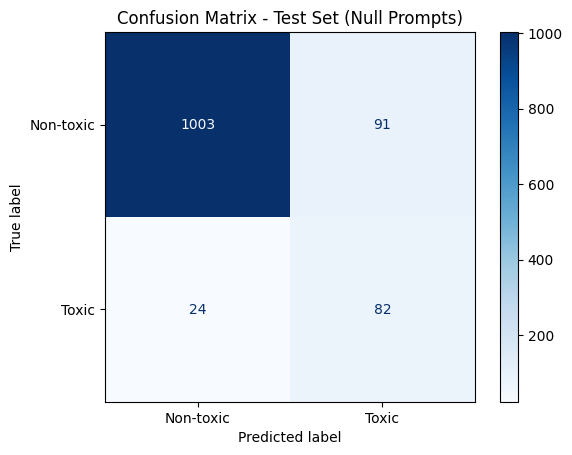

In [ ]:
test_probs, test_labels = evaluate_model(model, test_loader, device, v0_id, v1_id)

test_preds = (test_probs >= best_threshold).astype(int)

pr_auc = average_precision_score(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)

print("============ ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ============")
print(f"PR-AUC (Precision-Recall Area) : {pr_auc:.4f}")
print(f"ROC-AUC                        : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["Non-toxic", "Toxic"]))

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-toxic", "Toxic"])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Test Set (Null Prompts)")
plt.show()